# 02 探索性資料分析 (EDA)
本筆記本負責載入原始資料集，進行深入的資料探索與可視化分析。包含統計學型態分類分析、單變量分佈、時間序列分佈以及特徵相關性分析。

In [20]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 添加專案根目錄到 Python 路徑
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 匯入資料載入系統
from src.data_loader import DataLoader, ConfigLoader

# 載入配置
config = ConfigLoader.load_config(project_root / "config.yaml")
loader = DataLoader(config)

print("✅ 環境初始化完成")

2026-05-19 01:51:20,839 - src.data_loader - INFO - ✅ 設定檔已載入: c:\Users\chent\Desktop\我的資料夾\學校\大學\三下\統計方法與資料採礦\DataMiningG1FinalProject\config.yaml


✅ 環境初始化完成


In [21]:
# 方案 A：載入原始資料集進行 EDA
df = loader.load_raw_data()
print(f"✅ 原始資料載入成功！目前的欄位數量: {len(df.columns)}")
print(f"主要的類別型欄位是否存在: {[col for col in ['employment_type', 'product_category', 'location'] if col in df.columns] if 'df' in locals() else []}")
display(df.head())


2026-05-19 01:51:20,858 - src.data_loader - INFO - ✅ 優先使用專案本地資料: c:\Users\chent\Desktop\我的資料夾\學校\大學\三下\統計方法與資料採礦\DataMiningG1FinalProject\data\raw\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
2026-05-19 01:51:20,859 - src.data_loader - INFO - 📖 讀取資料檔案: c:\Users\chent\Desktop\我的資料夾\學校\大學\三下\統計方法與資料採礦\DataMiningG1FinalProject\data\raw\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
2026-05-19 01:51:20,879 - src.data_loader - INFO - ✅ 資料已載入 | 形狀: (10345, 17)


✅ 原始資料載入成功！目前的欄位數量: 17
主要的類別型欄位是否存在: ['employment_type', 'product_category', 'location']


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


## 1. 變數統計分類與摘要
根據統計學型態進行分類分析。

In [22]:
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'default_flag'],
    'Ordinal': ['customer_segment'],
    'Interval': ['credit_score', 'transaction_date'],
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
              'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
              'debt_to_income_ratio', 'risk_score']  
}

### 1.1 類別型變數 (Categorical)
分析眾數、比例與分佈。

=== Categorical 欄位統計 ===

employment_type:
  類別數量: 4
  眾數: Salaried (出現 2632 次)
  所有值: {'Salaried': 2632, 'Unemployed': 2632, 'Self-Employed': 2550, 'Student': 2531}

  各類別比例:
    Salaried: 2632 (25.4%)
    Unemployed: 2632 (25.4%)
    Self-Employed: 2550 (24.6%)
    Student: 2531 (24.5%)


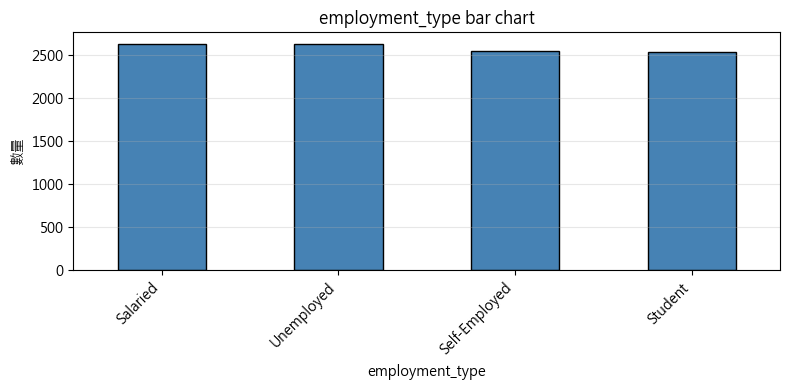

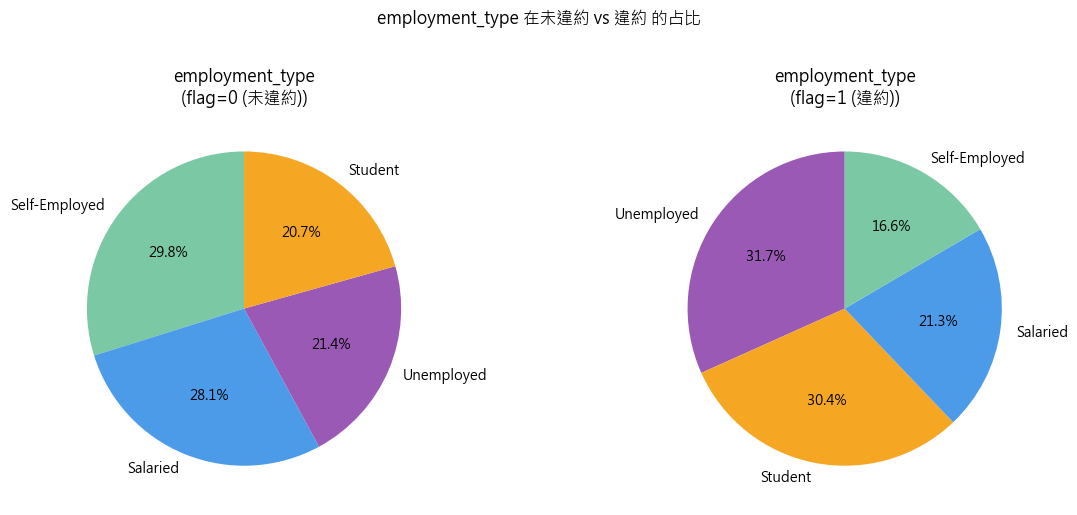

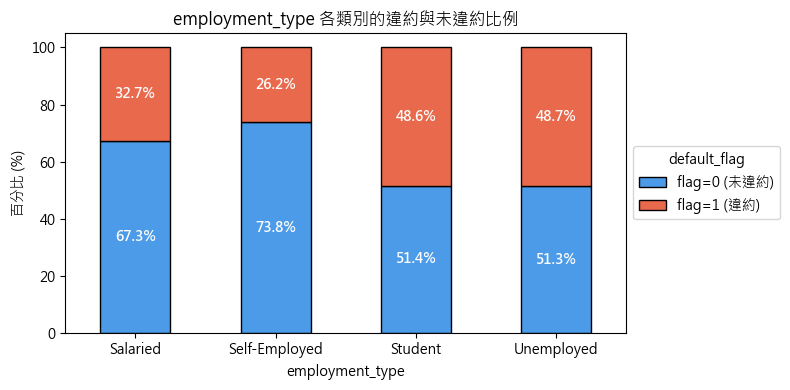


product_category:
  類別數量: 5
  眾數: Fashion (出現 2166 次)
  所有值: {'Fashion': 2166, 'Electronics': 2085, 'Beauty': 2072, 'Home': 2052, 'Sports': 1970}

  各類別比例:
    Fashion: 2166 (20.9%)
    Electronics: 2085 (20.2%)
    Beauty: 2072 (20.0%)
    Home: 2052 (19.8%)
    Sports: 1970 (19.0%)


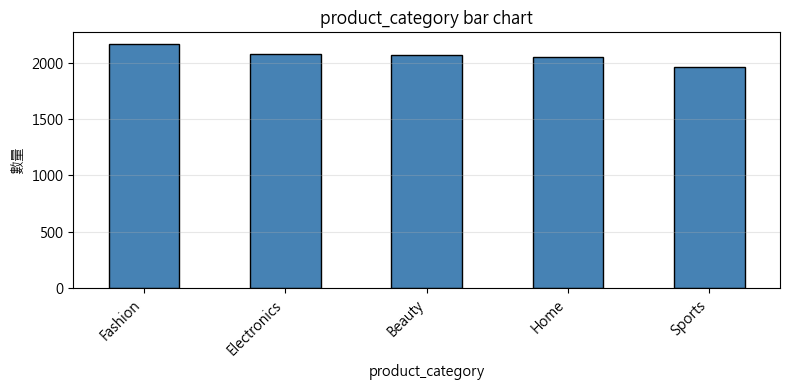

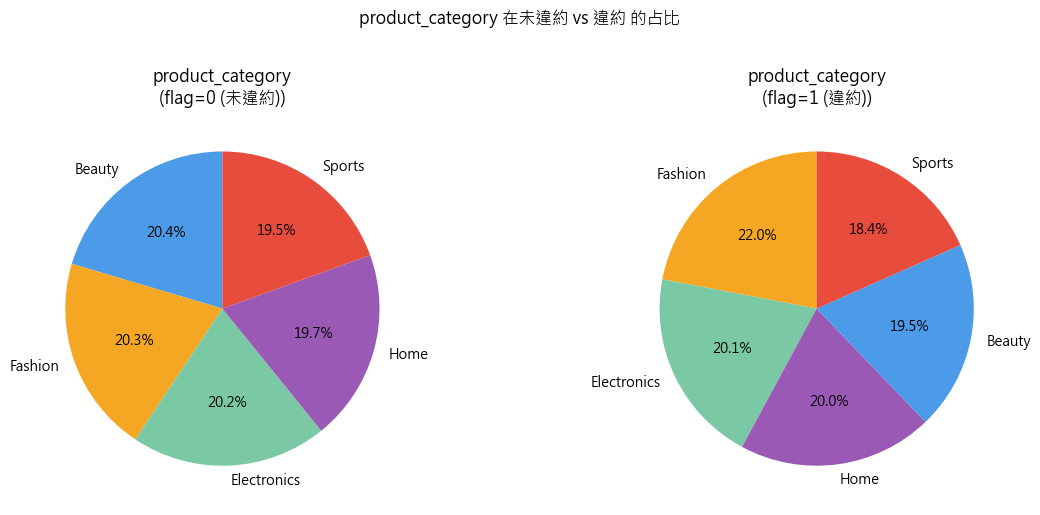

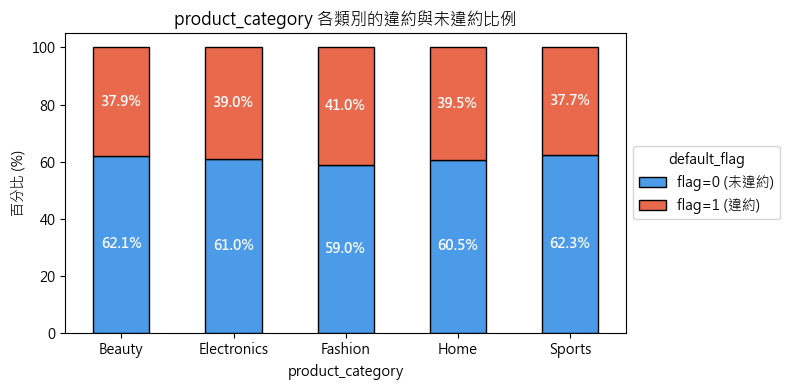


location:
  類別數量: 6
  眾數: Germany (出現 1760 次)
  所有值: {'Germany': 1760, 'Canada': 1740, 'USA': 1736, 'India': 1723, 'Australia': 1722, 'UK': 1664}

  各類別比例:
    Germany: 1760 (17.0%)
    Canada: 1740 (16.8%)
    USA: 1736 (16.8%)
    India: 1723 (16.7%)
    Australia: 1722 (16.6%)
    UK: 1664 (16.1%)


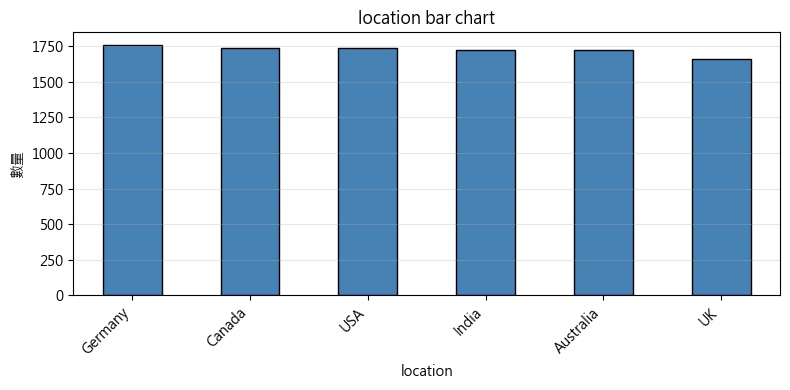

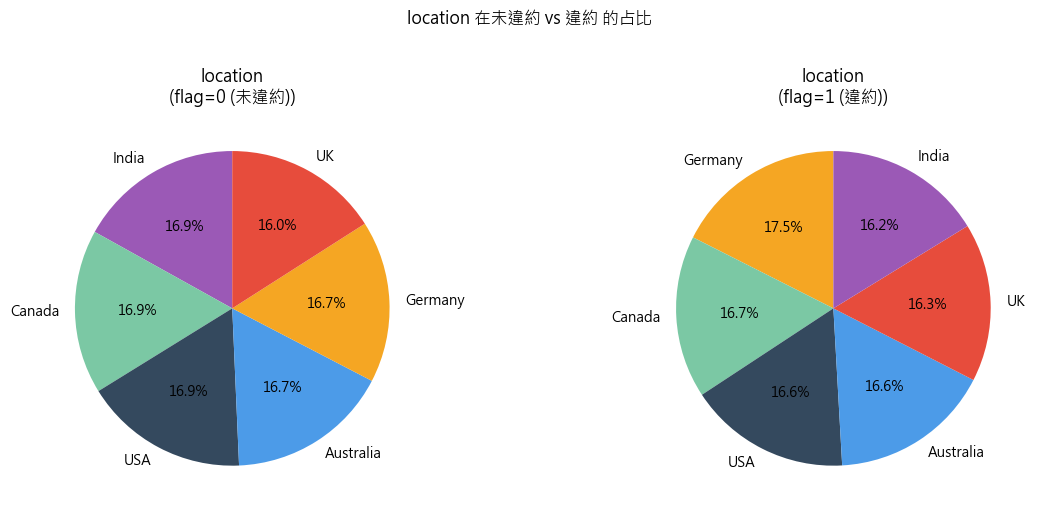

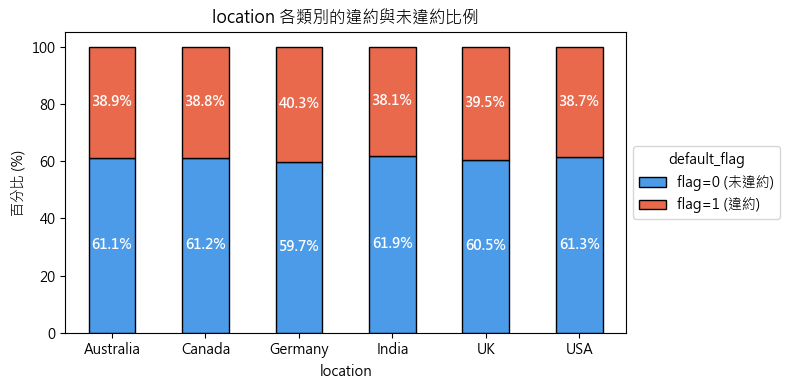


default_flag:
  類別數量: 2
  眾數: 0 (出現 6305 次)
  所有值: {0: 6305, 1: 4040}

  各類別比例:
    0: 6305 (60.9%)
    1: 4040 (39.1%)


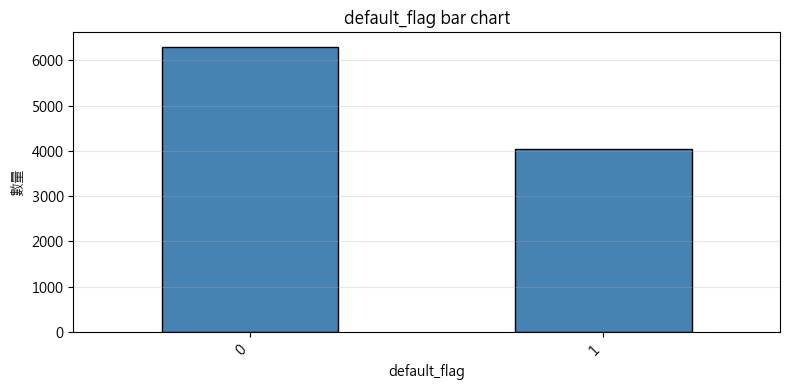

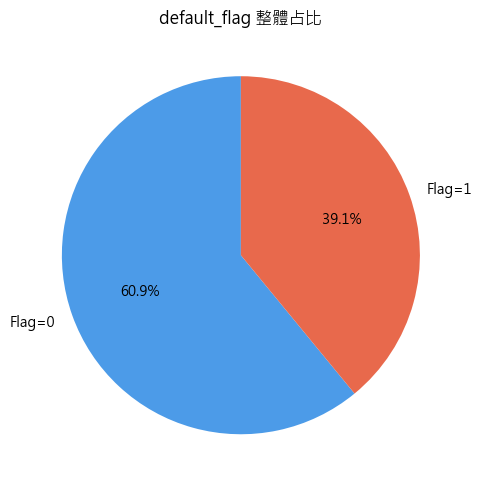

In [23]:
# Categorical統計
print("=== Categorical 欄位統計 ===")

flag_labels = {0: 'flag=0 (未違約)', 1: 'flag=1 (違約)'}

for col in data_types['Categorical']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  類別數量: {df[col].nunique()}")
        print(f"  眾數: {df[col].mode().iloc[0]} (出現 {df[col].value_counts().iloc[0]} 次)")
        print(f"  所有值: {df[col].value_counts().to_dict()}")

        print(f"\n  各類別比例:")
        value_counts = df[col].value_counts()
        total_count = len(df[col])
        for category, count in value_counts.items():
            percentage = (count / total_count) * 100
            print(f"    {category}: {count} ({percentage:.1f}%)")

        # 一般長條圖 (數量)
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
        plt.title(f"{col} bar chart")
        plt.xlabel(col)
        plt.ylabel('數量')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # 圓餅圖與新增的 100% 堆疊長條圖
        if col == 'default_flag':
            fig, ax = plt.subplots(figsize=(5, 5))
            vc = df[col].value_counts()
            ax.pie(vc, labels=[f"Flag={v}" for v in vc.index],
                   autopct='%1.1f%%', startangle=90,
                   colors=['#4C9BE8', '#E8694C'])
            ax.set_title(f"{col} 整體占比")
            plt.tight_layout()
            plt.show()
        else:
            # 1. 雙圓餅圖 (觀察違約 vs 未違約群體內的特徵分佈)
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            palette = ['#4C9BE8', '#7BC8A4', '#F5A623', '#9B59B6', '#E74C3C', '#34495E', '#2ECC71', '#16A085', '#27AE60', '#2980B9', '#8E44AD', '#F1C40F']
            unique_cats = sorted(df[col].dropna().unique())
            color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_cats)}
            
            for ax, flag_val in zip(axes, [0, 1]):
                subset = df[df['default_flag'] == flag_val][col].value_counts()
                subset_colors = [color_map[cat] for cat in subset.index]
                ax.pie(subset, labels=subset.index, autopct='%1.1f%%',
                       startangle=90, colors=subset_colors)
                ax.set_title(f"{col}\n({flag_labels[flag_val]})")
            plt.suptitle(f"{col} 在未違約 vs 違約 的占比", fontsize=12, y=1.02)
            plt.tight_layout()
            plt.show()

            # ---------------------------------------------------------
            # 2. 新增：100% 堆疊長條圖 (觀察各特徵類別內部的違約機率)
            # ---------------------------------------------------------
            # 使用 pd.crosstab 產生交叉表，並設定 normalize='index' 計算橫向百分比
            cross_tab = pd.crosstab(df[col], df['default_flag'], normalize='index') * 100
            
            # 繪製圖表
            ax = cross_tab.plot(kind='bar', stacked=True, figsize=(8, 4), 
                                color=['#4C9BE8', '#E8694C'], edgecolor='black')
            
            plt.title(f"{col} 各類別的違約與未違約比例")
            plt.xlabel(col)
            plt.ylabel('百分比 (%)')
            
            # 將圖例移到圖表外側避免遮擋
            plt.legend([flag_labels[0], flag_labels[1]], title='default_flag', loc='center left', bbox_to_anchor=(1, 0.5))
            
            # 在長條圖區塊中心印上百分比數值
            for c in ax.containers:
                # 只有當高度(百分比)大於 0 時才標示數字，避免太擠
                labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
                ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()


### 1.2 順序型變數 (Ordinal)
將 `customer_segment` 映射為數值進行分析。

=== Ordinal 欄位統計 ===
Ordinal 欄位清單: ['customer_segment']
資料集欄位包含 Ordinal 欄位: ['customer_segment']

customer_segment:
  數值映射: {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
  總數: 10345
  中位數: 2.00
  眾數: 2
  最小值: 0
  最大值: 2

  各類別比例:
    High Risk: 7569 (73.2%)
    Medium Risk: 2200 (21.3%)
    Low Risk: 576 (5.6%)


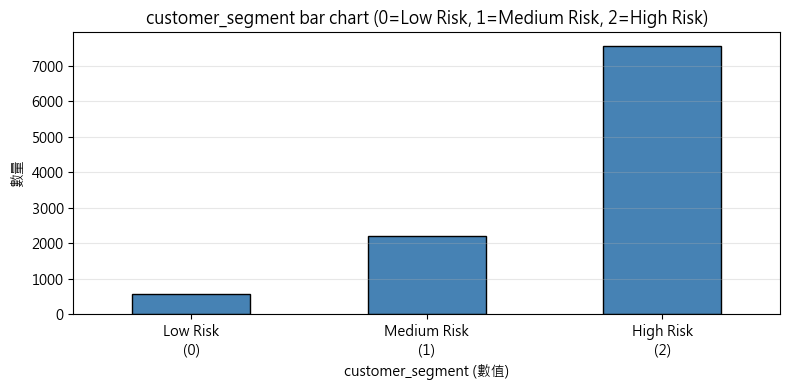

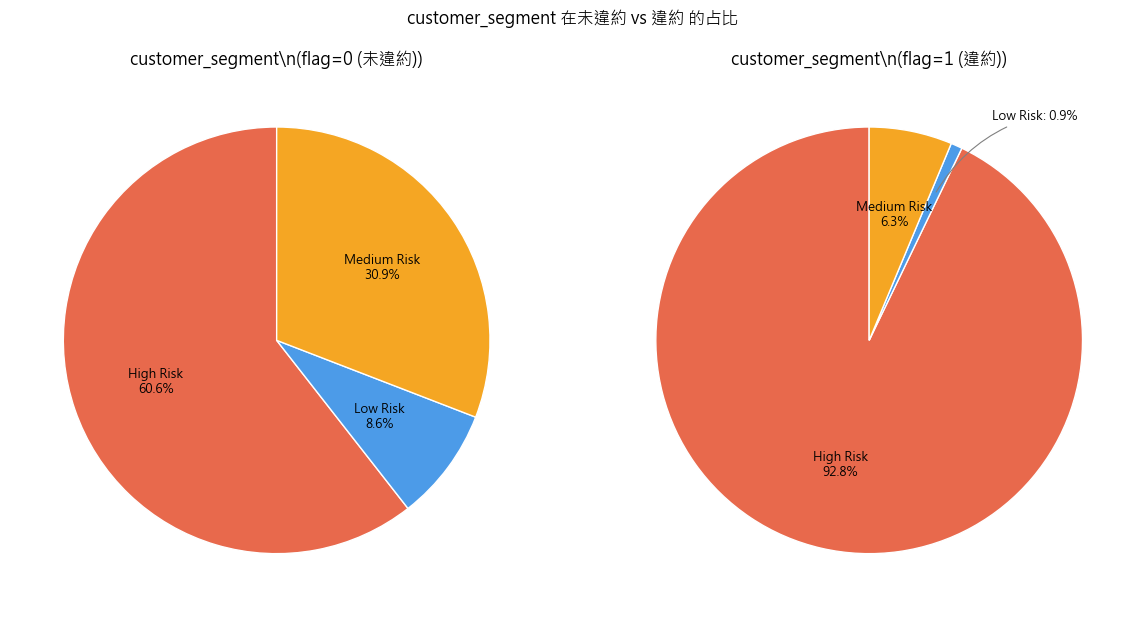

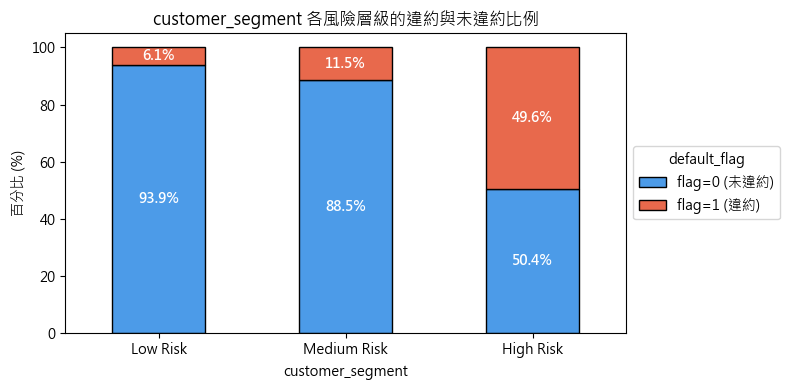

In [24]:
def draw_pie_with_leaders(ax, data_series, colors=None, small_pct=5):
    series = data_series.copy()
    total = series.sum()
    if total == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return
        
    # 直接抓取所有標籤與數值，不做任何合併！
    labels = series.index.astype(str)
    sizes = series.values
    
    # 準備顏色
    if colors is None or len(colors) < len(sizes):
        colors = plt.cm.tab20(np.linspace(0, 1, len(sizes)))
        
    wedges, _ = ax.pie(sizes, labels=None, startangle=90, colors=colors[:len(sizes)], wedgeprops=dict(edgecolor='white'))
    
    # 開始標註：較大的切片在內部顯示，較小的切片往外拉引導線 (但各自獨立)
    for w, label, size in zip(wedges, labels, sizes):
        pct_v = size / total * 100
        ang = (w.theta2 + w.theta1) / 2.0
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        
        # 如果該切片比例小於 small_pct (預設5%)，就向外拉引導線
        if pct_v < small_pct:
            ha = 'left' if x >= 0 else 'right'
            # 避免上方標籤撞到標題的微調邏輯
            y_multiplier = 1.15 if y > 0 else 1.3 
            x_multiplier = 1.4
            
            ax.annotate(f"{label}: {pct_v:.1f}%", xy=(x * 0.75, y * 0.75), xytext=(x * x_multiplier, y * y_multiplier),
                        ha=ha, va='center', fontsize=9,
                        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, connectionstyle='arc3,rad=0.2'))
        else:
            # 比例夠大的，直接寫在圓餅圖內部
            ax.text(x * 0.6, y * 0.6, f"{label}\n{pct_v:.1f}%", ha='center', va='center', fontsize=9)
            
    ax.set_aspect('equal')
    return

# Ordinal 統計
print("=== Ordinal 欄位統計 ===")
print(f"Ordinal 欄位清單: {data_types['Ordinal']}")
print(f"資料集欄位包含 Ordinal 欄位: {[col for col in data_types['Ordinal'] if col in df.columns]}")

segment_mapping = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
flag_labels = {0: 'flag=0 (未違約)', 1: 'flag=1 (違約)'}

for col in data_types['Ordinal']:
    if col in df.columns:
        print(f"\n{col}:")

        if col == 'customer_segment':
            if not pd.api.types.is_numeric_dtype(df[col]):
                df_numeric = df[col].map(segment_mapping)
            else:
                df_numeric = df[col]
            print(f"  數值映射: {segment_mapping}")
            print(f"  總數: {df_numeric.count()}")
            print(f"  中位數: {pd.to_numeric(df_numeric, errors='coerce').median():.2f}")
            print(f"  眾數: {df_numeric.mode().iloc[0]}")
            print(f"  最小值: {df_numeric.min()}")
            print(f"  最大值: {df_numeric.max()}")

            print(f"\n  各類別比例:")
            value_counts = df[col].value_counts()
            total_count = len(df[col])
            for category, count in value_counts.items():
                percentage = (count / total_count) * 100
                print(f"    {category}: {count} ({percentage:.1f}%)")

            # 長條圖
            plt.figure(figsize=(8, 4))
            df_numeric.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart (0=Low Risk, 1=Medium Risk, 2=High Risk)")
            plt.xlabel(f"{col} (數值)")
            plt.ylabel('數量')
            plt.xticks([0, 1, 2], ['Low Risk\n(0)', 'Medium Risk\n(1)', 'High Risk\n(2)'], rotation=0)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

            # 圓餅圖：百分比放進 legend，扇形上不顯示文字
            segment_order = ['Low Risk', 'Medium Risk', 'High Risk']
            colors = ['#4C9BE8', '#F5A623', '#E8694C']
            color_map = {cat: color for cat, color in zip(segment_order, colors)}
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            for ax, flag_val in zip(axes, [0, 1]):
                subset = df[df['default_flag'] == flag_val][col].value_counts().sort_index()
                if subset.empty:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                    ax.axis('off')
                    continue
                subset_colors = [color_map[cat] for cat in subset.index]
                # 使用合併小切片的繪圖函式
                draw_pie_with_leaders(ax, subset, colors=subset_colors, small_pct=5)
                ax.set_title(f"{col}\\n({flag_labels.get(flag_val, flag_val)})")
            plt.suptitle(f"{col} 在未違約 vs 違約 的占比", fontsize=12, y=1.02)
            plt.tight_layout()
            plt.show()

            # ---------------------------------------------------------
            # 2. 新增：100% 堆疊長條圖 (觀察各特徵類別內部的違約機率)
            # ---------------------------------------------------------
            # 使用 pd.crosstab 產生交叉表，並設定 normalize='index' 計算橫向百分比
            cross_tab = pd.crosstab(df_numeric, df['default_flag'], normalize='index') * 100
            
            # 繪製圖表
            ax = cross_tab.plot(kind='bar', stacked=True, figsize=(8, 4), 
                                color=['#4C9BE8', '#E8694C'], edgecolor='black')
            
            plt.title(f"{col} 各風險層級的違約與未違約比例")
            plt.xlabel(col)
            plt.ylabel('百分比 (%)')
            
            # 將圖例移到圖表外側避免遮擋
            plt.legend([flag_labels[0], flag_labels[1]], title='default_flag', loc='center left', bbox_to_anchor=(1, 0.5))
            
            # 在長條圖區塊中心印上百分比數值
            for c in ax.containers:
                # 只有當高度(百分比)大於 0 時才標示數字，避免太擠
                labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
                ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

            plt.xticks([0, 1, 2], ['Low Risk', 'Medium Risk', 'High Risk'], rotation=0)
            plt.tight_layout()
            plt.show()


### 1.3 區間型變數 (Interval)
分析數值分佈與集中趨勢。

=== Interval 欄位統計 (非時間型) ===
Interval 欄位清單: ['credit_score', 'transaction_date']
資料集欄位包含 Interval 欄位: ['credit_score', 'transaction_date']

credit_score:
  總數: 10345
  平均: 448.18
  中位數: 403.00
  眾數: 300
  最小值: 300
  最大值: 850
  標準差: 136.52


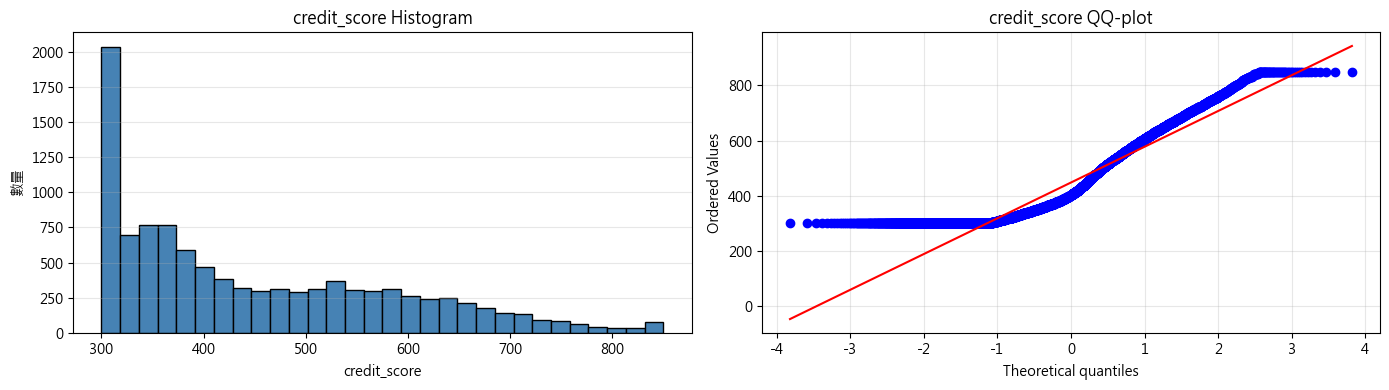

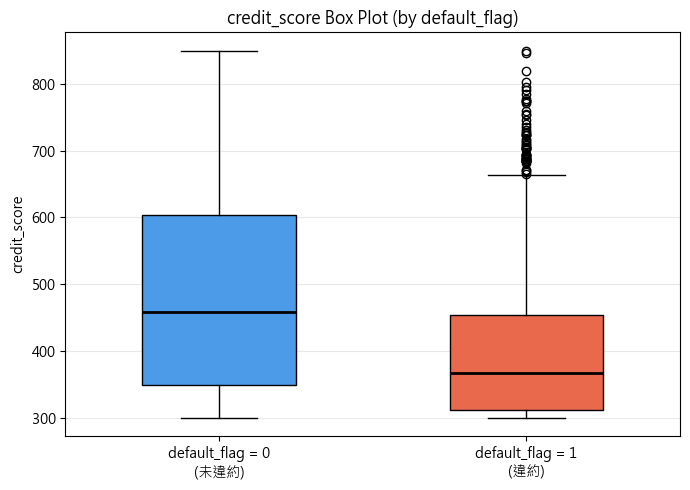

In [25]:
# Interval 統計 (非時間型)
print("=== Interval 欄位統計 (非時間型) ===")
print(f"Interval 欄位清單: {data_types['Interval']}")
print(f"資料集欄位包含 Interval 欄位: {[col for col in data_types['Interval'] if col in df.columns]}")

for col in data_types['Interval']:
    if col in df.columns and col != 'transaction_date':
        print(f"\n{col}:")
        print(f"  總數: {df[col].count()}")
        print(f"  平均: {df[col].mean():.2f}")
        print(f"  中位數: {df[col].median():.2f}")
        print(f"  眾數: {df[col].mode().iloc[0]}")
        print(f"  最小值: {df[col].min()}")
        print(f"  最大值: {df[col].max()}")
        print(f"  標準差: {df[col].std():.2f}")
        
        # 直方圖 + QQ-plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].hist(df[col], bins=30, color='steelblue', edgecolor='black')
        axes[0].set_title(f"{col} Histogram")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('數量')
        axes[0].grid(axis='y', alpha=0.3)
        stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title(f"{col} QQ-plot")
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Box plot：依 default_flag 分組
        fig, ax = plt.subplots(figsize=(7, 5))
        groups = [df[df['default_flag'] == v][col].dropna() for v in [0, 1]]
        bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor('#4C9BE8')
        bp['boxes'][1].set_facecolor('#E8694C')
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['default_flag = 0\n(未違約)', 'default_flag = 1\n(違約)'])
        ax.set_title(f"{col} Box Plot (by default_flag)")
        ax.set_ylabel(col)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### 1.4 比率型變數 (Ratio)
分析數值分佈與集中趨勢。

用 IQR 看 outliner

欄位名稱                 | 離群值數量  | 邊界範圍                
-------------------------------------------------------
age                  |          0 | [   -3.50,    80.50]
monthly_income       |         25 | [-52397.85, 119881.80]
purchase_amount      |          0 | [  -23.20,  8013.92]
bnpl_installments    |          0 | [   -6.00,    18.00]
repayment_delay_days |          1 | [  -16.00,    32.00]
missed_payments      |          8 | [   -3.00,     5.00]
app_usage_frequency  |          0 | [   -3.38,    14.43]
debt_to_income_ratio |         57 | [   -0.20,     0.55]
risk_score           |         31 | [    7.80,   396.60]
credit_score         |          0 | [    9.50,   869.50]


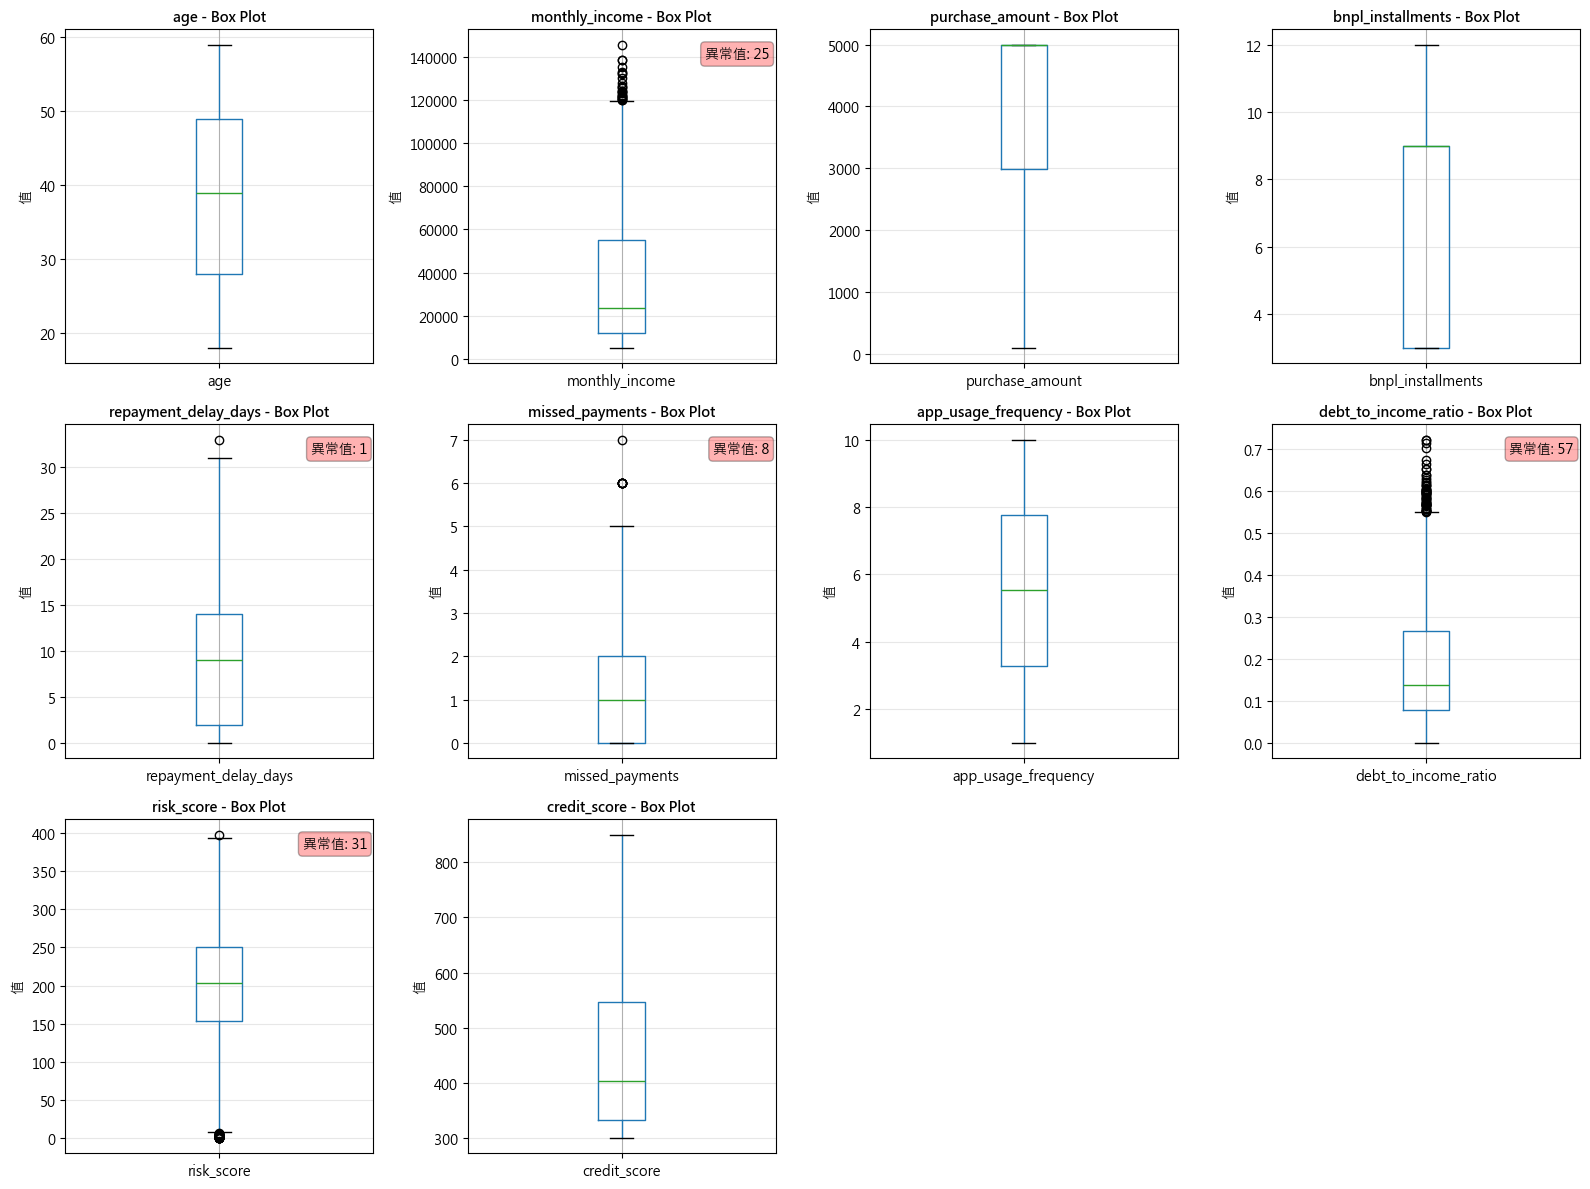

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,52,Student,17344.34,393,5000.00,Fashion,6,0,0,1,4.33,USA,2024-10-25,0.288278,182.8,High Risk
10341,10342,53,Student,17788.20,300,100.00,Sports,12,12,1,0,1.41,Australia,2023-06-15,0.005622,264.0,High Risk
10342,10343,42,Self-Employed,59350.25,535,5000.00,Home,12,4,2,0,5.07,Australia,2024-09-24,0.084246,174.0,High Risk
10343,10344,59,Self-Employed,73739.74,678,5000.00,Beauty,3,2,0,0,8.89,Germany,2023-01-19,0.067806,72.8,Medium Risk


In [26]:
def handle_outliers_iqr(data, columns):
    df_clean = data.copy()
    
    print(f"{'欄位名稱':<20} | {'離群值數量':<6} | {'邊界範圍':<20}")
    print("-" * 55)

    # 繪製 Box Plot
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for idx, col in enumerate(columns):
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outliers_mask.sum()
        
        print(f"{col:20} | {num_outliers:10} | [{lower_bound:8.2f}, {upper_bound:8.2f}]")
        
        ax = axes[idx]
        df.boxplot(column=col, ax=ax)
        ax.set_title(f"{col} - Box Plot", fontsize=10, fontweight='bold')
        ax.set_ylabel('值')
        ax.grid(axis='y', alpha=0.3)
        
        # 標記異常值數量
        if num_outliers > 0:
            ax.text(0.98, 0.95, f"異常值: {num_outliers}", 
                    transform=ax.transAxes, ha='right', va='top',
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))   

    # 隱藏子圖
    axes[-1].axis('off')
    axes[-2].axis('off')

    plt.tight_layout()
    plt.show()

    return df_clean

target_columns = data_types['Ratio'] + ['credit_score']

handle_outliers_iqr(df, target_columns)

=== Ratio 欄位統計 ===

age:


count    10345.000000
mean        38.559884
std         12.131789
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

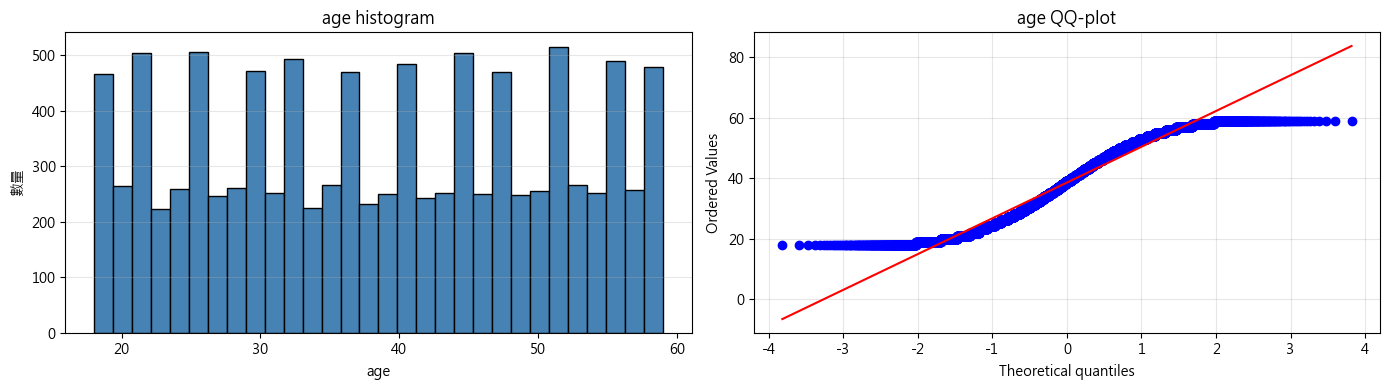

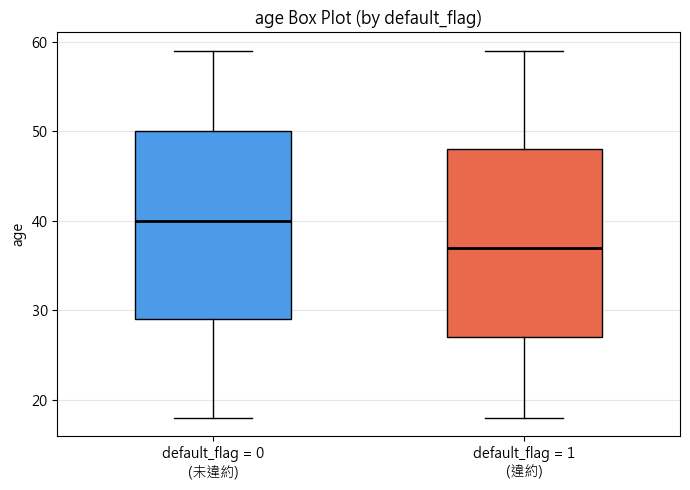


monthly_income:


count     10345.000000
mean      35053.381898
std       27084.517277
min        5000.000000
25%       12207.020000
50%       23800.520000
75%       55276.930000
max      145767.120000
Name: monthly_income, dtype: float64

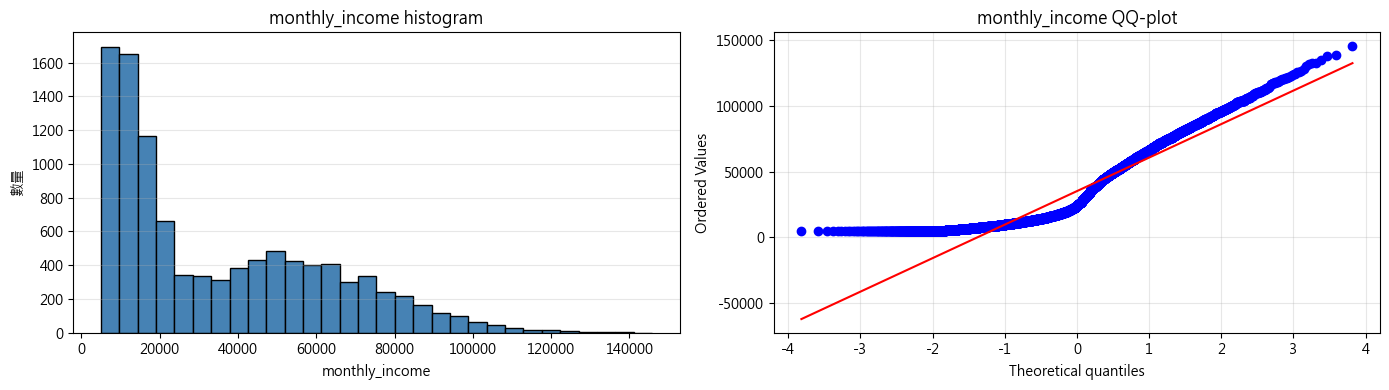

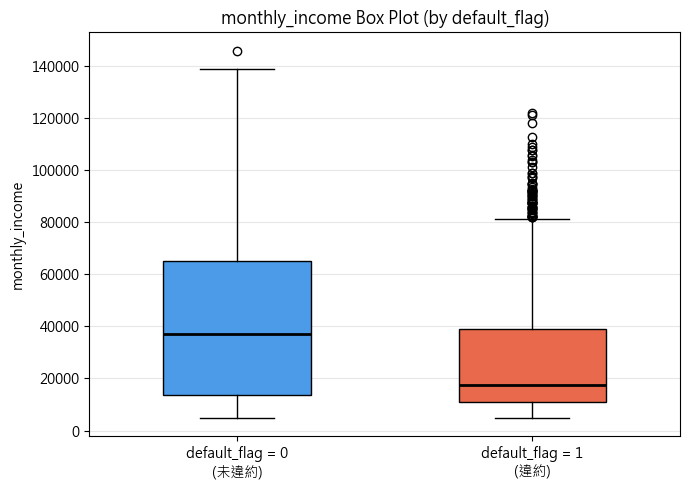


purchase_amount:


count    10345.000000
mean      3979.402721
std       1500.828483
min        100.000000
25%       2990.720000
50%       5000.000000
75%       5000.000000
max       5000.000000
Name: purchase_amount, dtype: float64

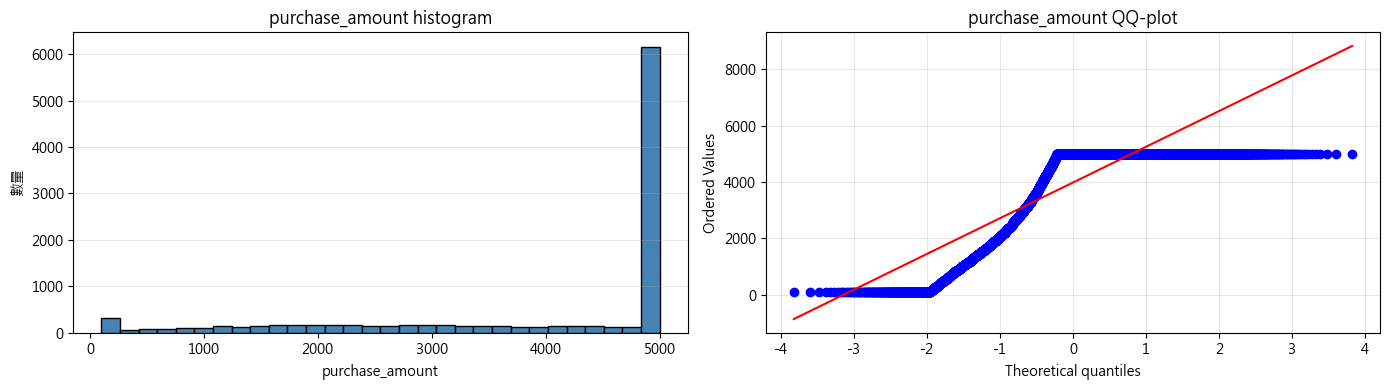

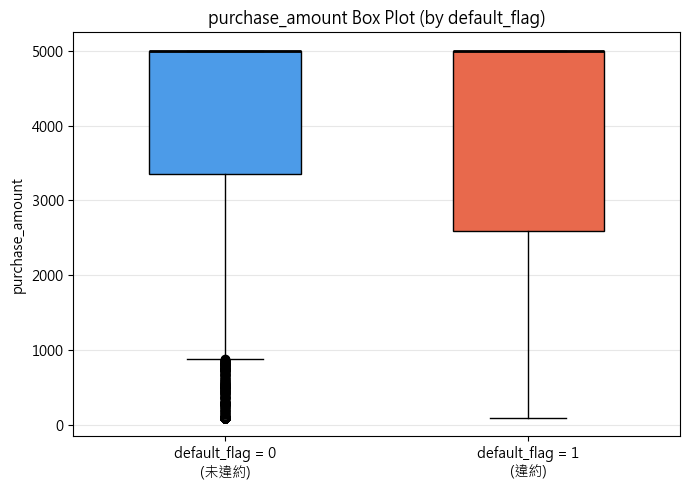


bnpl_installments:


count    10345.000000
mean         7.477525
std          3.362867
min          3.000000
25%          3.000000
50%          9.000000
75%          9.000000
max         12.000000
Name: bnpl_installments, dtype: float64

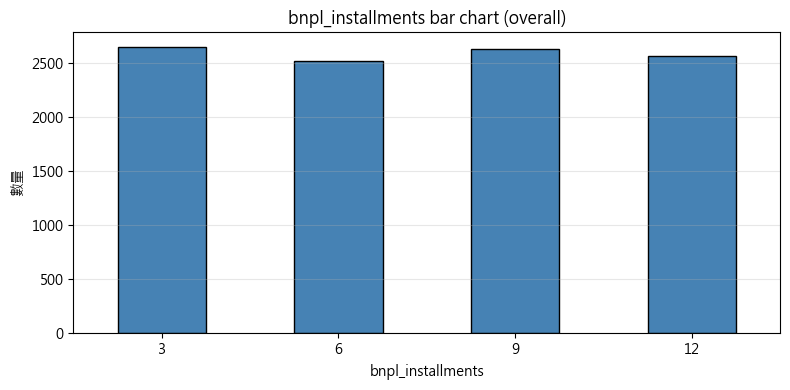

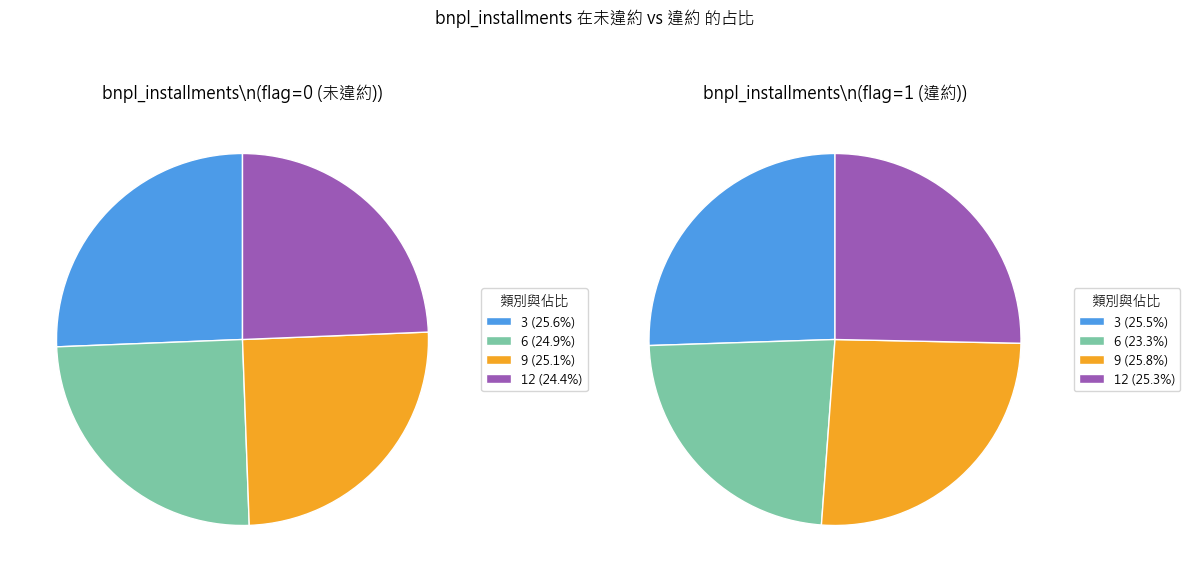


repayment_delay_days:


count    10345.000000
mean         8.742774
std          6.781849
min          0.000000
25%          2.000000
50%          9.000000
75%         14.000000
max         33.000000
Name: repayment_delay_days, dtype: float64

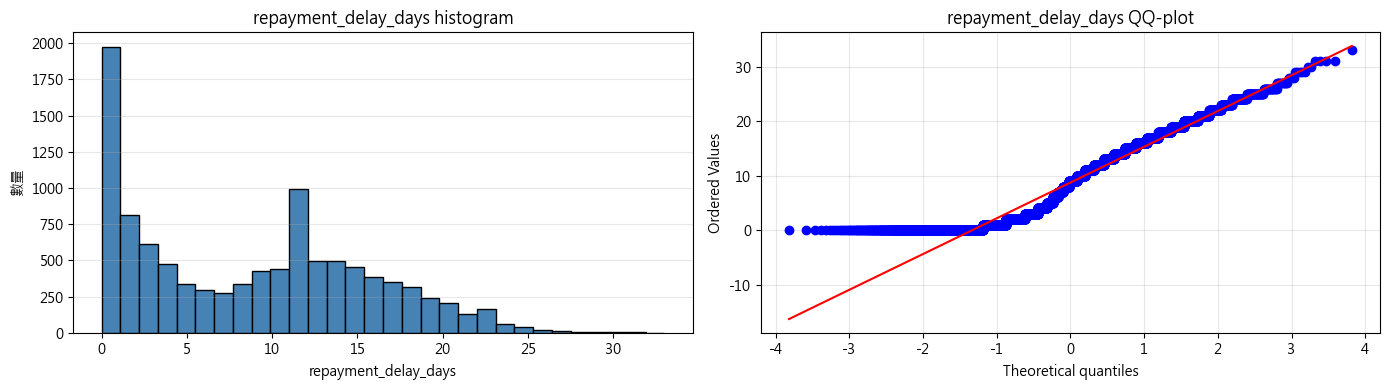

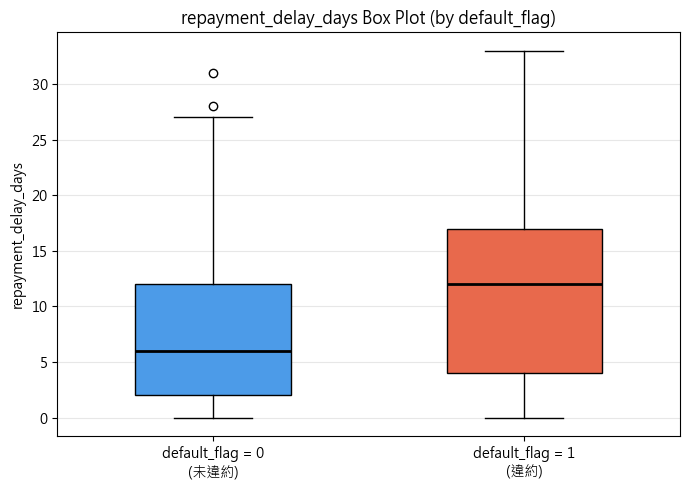


missed_payments:


count    10345.000000
mean         1.015950
std          0.996726
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: missed_payments, dtype: float64

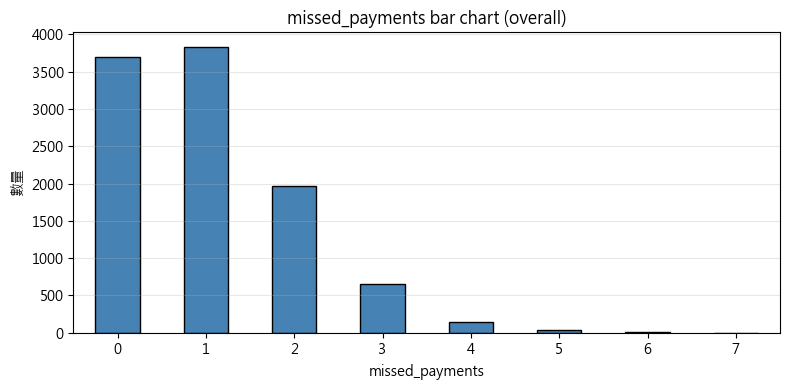

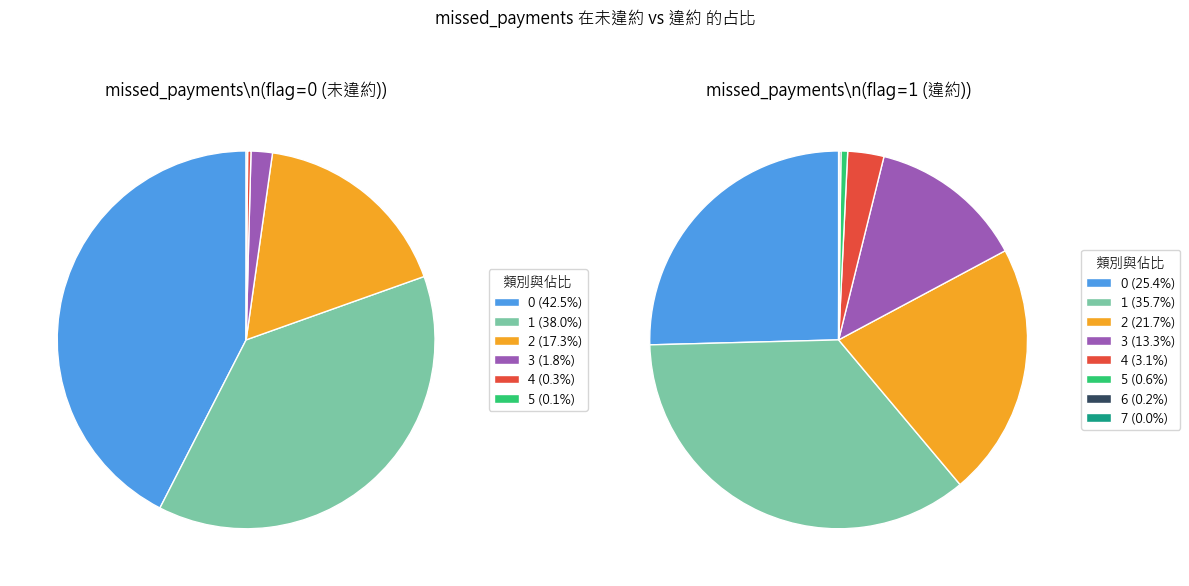


app_usage_frequency:


count    10345.000000
mean         5.524101
std          2.590364
min          1.000000
25%          3.300000
50%          5.550000
75%          7.750000
max         10.000000
Name: app_usage_frequency, dtype: float64

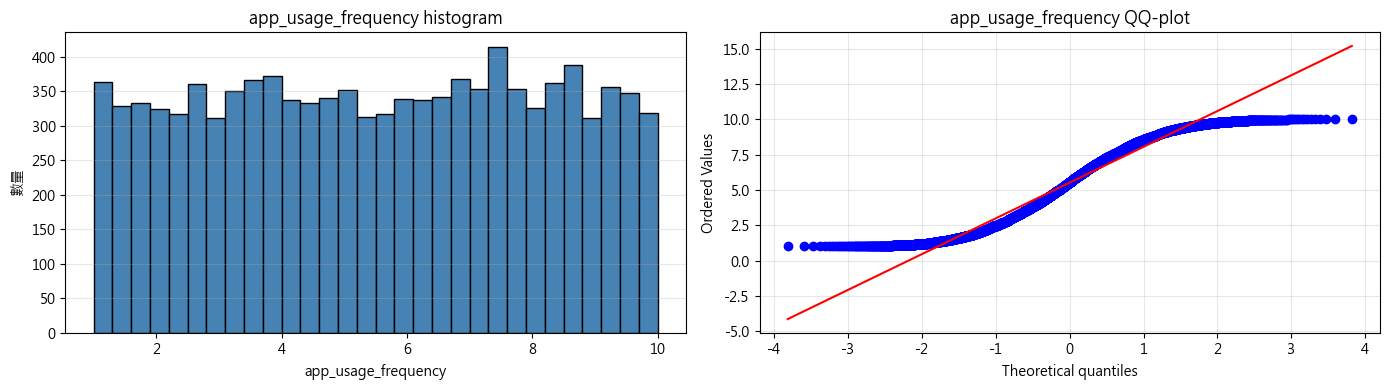

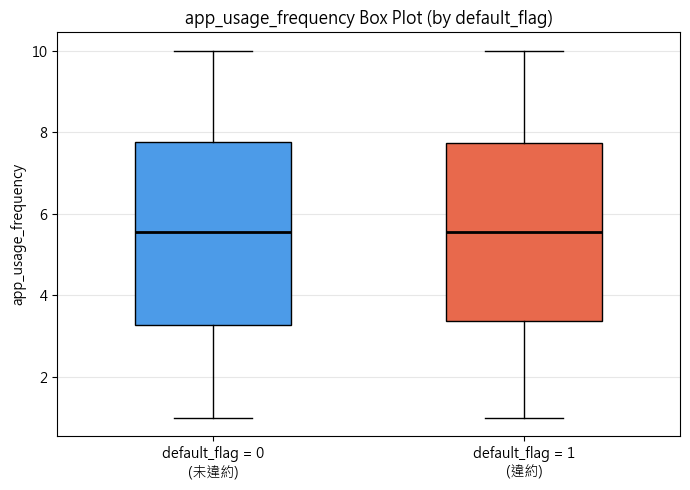


debt_to_income_ratio:


count    10345.000000
mean         0.181071
std          0.124887
min          0.000811
25%          0.080187
50%          0.138263
75%          0.268300
max          0.723460
Name: debt_to_income_ratio, dtype: float64

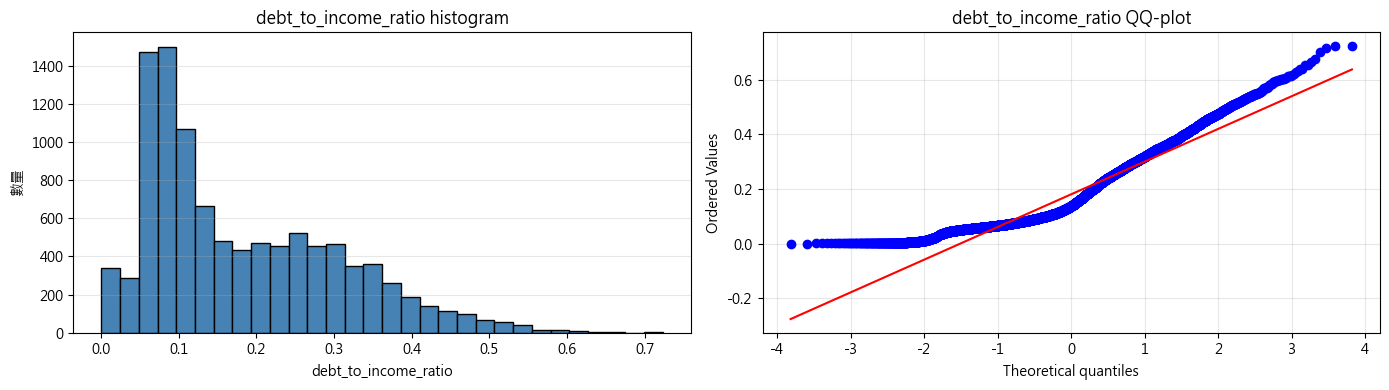

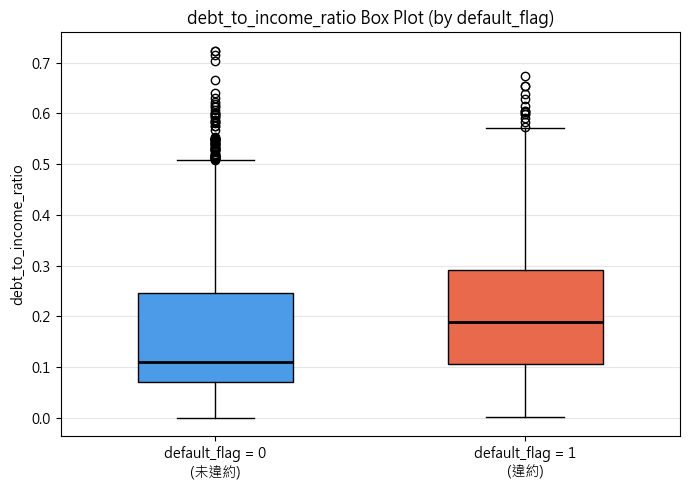


risk_score:


count    10345.000000
mean       198.534094
std         67.541384
min          0.000000
25%        153.600000
50%        202.800000
75%        250.800000
max        398.000000
Name: risk_score, dtype: float64

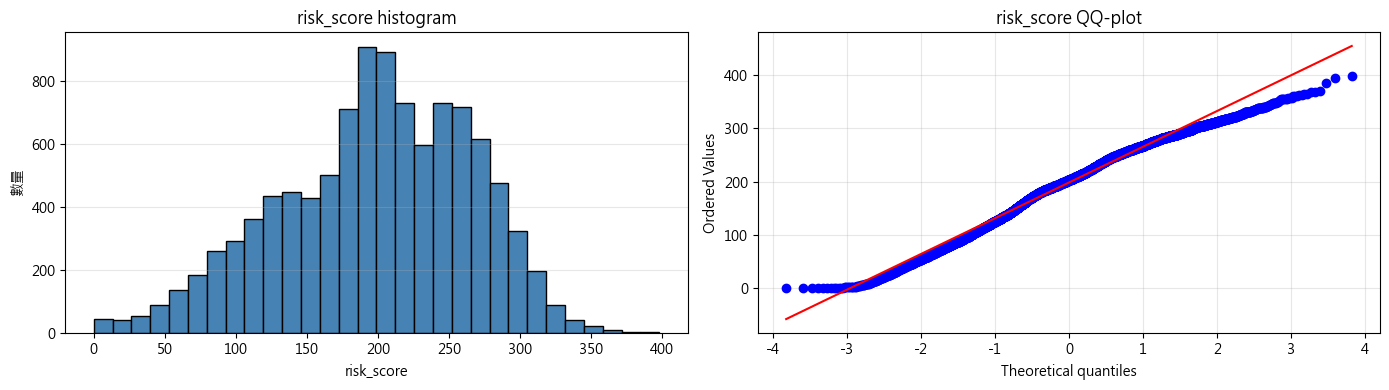

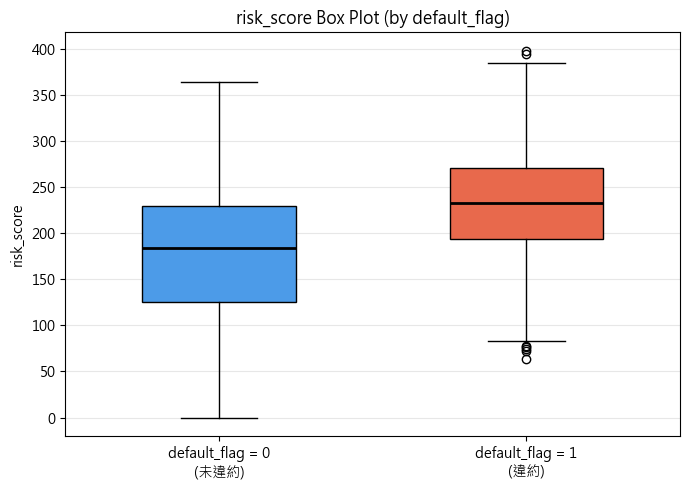

In [27]:
def draw_pie_with_leaders(ax, data_series, colors=None, small_pct=5):
    series = data_series.copy()
    total = series.sum()
    if total == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return
        
    labels = series.index.astype(str)
    sizes = series.values
    
    if colors is None or len(colors) < len(sizes):
        colors = plt.cm.tab20(np.linspace(0, 1, len(sizes)))
        
    # autopct='' 讓圓餅圖自己不上字，我們用 legend 來顯示
    wedges, _ = ax.pie(sizes, startangle=90, colors=colors[:len(sizes)], wedgeprops=dict(edgecolor='white'))
    
    # 準備圖例的文字 (名稱 + 百分比)
    legend_labels = [f"{label} ({size/total*100:.1f}%)" for label, size in zip(labels, sizes)]
    
    # 將圖例放在圖表的右側外面 (bbox_to_anchor 是定位神器)
    ax.legend(wedges, legend_labels, title="類別與佔比", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
    
    ax.set_aspect('equal')
    return


#Ratio統計
print("=== Ratio 欄位統計 ===")
flag_labels = {0: 'flag=0 (未違約)', 1: 'flag=1 (違約)'}

for col in data_types['Ratio']:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe().T)

        # 特殊處理：特定欄位使用長條圖（保留原始整體 bar chart，並加入依 default_flag 的分組 pie chart）
        if col in ['default_flag', 'missed_payments', 'bnpl_installments']:
            # 先顯示原始整體 bar chart（保留原有視覺化）
            plt.figure(figsize=(8, 4))
            df[col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart (overall)")
            plt.xlabel(col)
            plt.ylabel('數量')
            plt.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
            # 若欄位不是 default_flag，本欄位可依 default_flag 分組顯示比較（顯示兩個 pie chart）
            if col != 'default_flag':
                fig, axes = plt.subplots(1, 2, figsize=(12, 6))
                palette = ['#4C9BE8', '#7BC8A4', '#F5A623', '#9B59B6', '#E74C3C', '#2ECC71', '#34495E', '#16A085', '#27AE60', '#2980B9', '#8E44AD', '#F1C40F']
                unique_cats = sorted(df[col].dropna().unique())
                color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_cats)}
                for ax, flag_val in zip(axes, [0, 1]):
                    subset = df[df['default_flag'] == flag_val][col].value_counts().sort_index()
                    if subset.empty:
                        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                        ax.axis('off')
                        continue
                    subset_colors = [color_map[cat] for cat in subset.index]
                    # 使用合併小切片的繪圖函式
                    draw_pie_with_leaders(ax, subset, colors=subset_colors, small_pct=5)
                    ax.set_title(f"{col}\\n({flag_labels.get(flag_val, flag_val)})")
                plt.suptitle(f"{col} 在未違約 vs 違約 的占比", fontsize=12, y=1.02)
                plt.tight_layout()
                plt.show()
        else:
            # 其他欄位使用直方圖與 QQ-plot
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # 直方圖
            axes[0].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
            axes[0].set_title(f"{col} histogram")
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('數量')
            axes[0].grid(axis='y', alpha=0.3)
            
            # QQ-plot
            stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
            axes[1].set_title(f"{col} QQ-plot")
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()

        # 依 default_flag 分組繪製 Box plot（僅對非 bar-chart 的 ratio 欄位）
        if col not in ['missed_payments', 'bnpl_installments']:
            fig, ax = plt.subplots(figsize=(7, 5))
            groups = [df[df['default_flag'] == v][col].dropna() for v in [0, 1]]
            bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                            medianprops=dict(color='black', linewidth=2))
            bp['boxes'][0].set_facecolor('#4C9BE8')
            bp['boxes'][1].set_facecolor('#E8694C')
            ax.set_xticks([1, 2])
            ax.set_xticklabels(['default_flag = 0\n(未違約)', 'default_flag = 1\n(違約)'])
            ax.set_title(f"{col} Box Plot (by default_flag)")
            ax.set_ylabel(col)
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

## 2. 時間序列特徵分析
觀察交易在不同時間維度的分佈。

=== 時間型 Interval 統計與特徵工程 ===
非時間型 Interval 欄位 'credit_score' 在其他地方處理

transaction_date:
  總數: 10345
  開始時間: 2023-01-01 00:00:00
  結束時間: 2024-12-31 00:00:00
  時間跨度: 730 天
  缺失值: 0

  提取的特徵:
    - transaction_date_year
    - transaction_date_month
    - transaction_date_day
    - transaction_date_dayofweek (0=Monday, 6=Sunday)
    - transaction_date_is_weekend (1=Weekend, 0=Weekday)

  各時間特徵比例:

    transaction_date_year:
      2023: 5145 (49.7%)
      2024: 5200 (50.3%)

    transaction_date_month:
      1月: 899 (8.7%)
      2月: 823 (8.0%)
      3月: 895 (8.7%)
      4月: 858 (8.3%)
      5月: 808 (7.8%)
      6月: 862 (8.3%)
      7月: 874 (8.4%)
      8月: 868 (8.4%)
      9月: 876 (8.5%)
      10月: 853 (8.2%)
      11月: 868 (8.4%)
      12月: 861 (8.3%)

    transaction_date_dayofweek:
      Monday: 1481 (14.3%)
      Tuesday: 1514 (14.6%)
      Wednesday: 1462 (14.1%)
      Thursday: 1476 (14.3%)
      Friday: 1480 (14.3%)
      Saturday: 1410 (13.6%)
      Sunday: 1522 (14.7%)

    transac

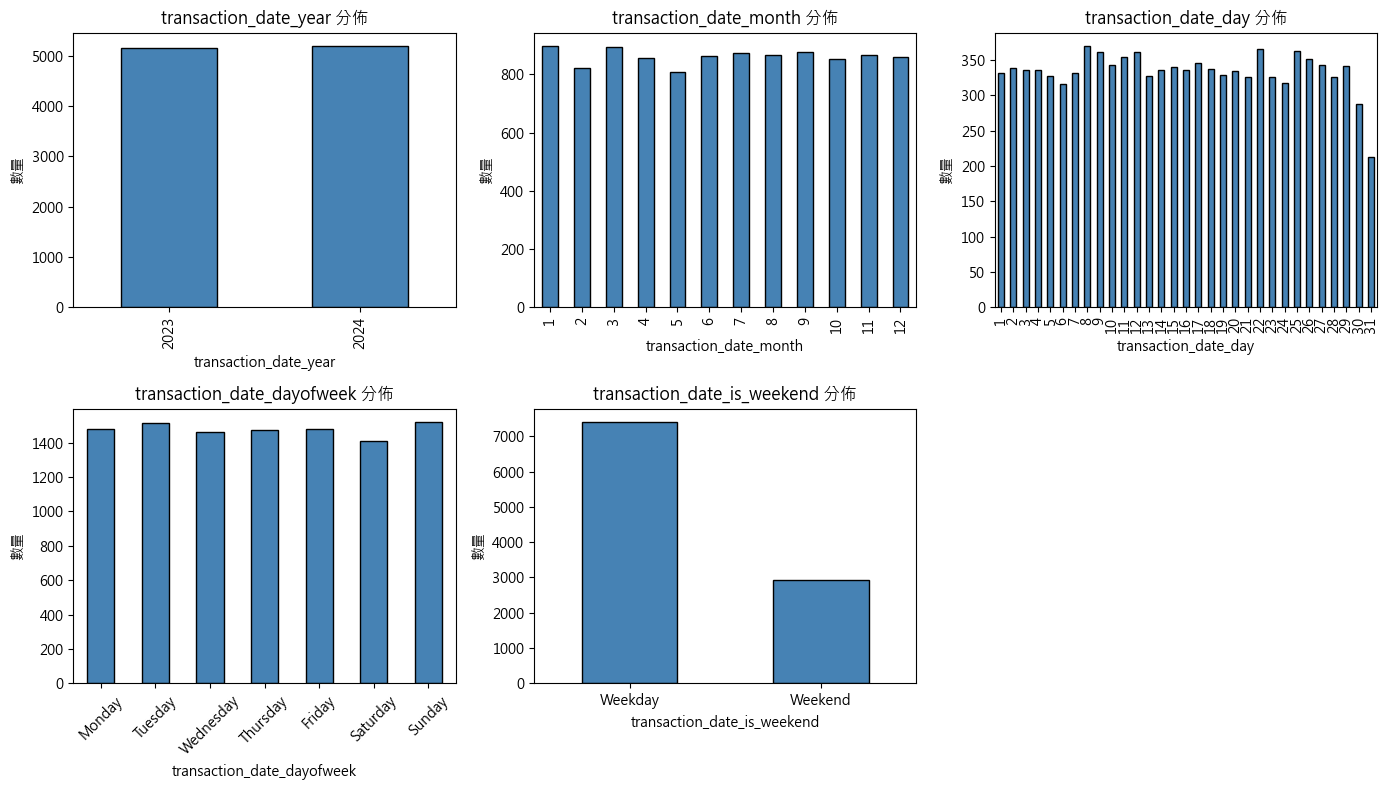

In [28]:
# 時間型 Interval 統計與特徵工程
print("=== 時間型 Interval 統計與特徵工程 ===")
for col in data_types['Interval']:
    if col in df.columns and col == 'transaction_date':  # 只處理 transaction_date
        print(f"\n{col}:")
        # 轉換為 datetime 如果還未轉換 (避免 dtype 為 'string' 而被跳過)
        if not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # 統計摘要
        print(f"  總數: {df[col].count()}")
        print(f"  開始時間: {df[col].min()}")
        print(f"  結束時間: {df[col].max()}")
        print(f"  時間跨度: {(df[col].max() - df[col].min()).days} 天")
        print(f"  缺失值: {df[col].isna().sum()}")
        
        # 時間特徵工程：提取年、月、日、星期幾、是否週末
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek  # 0=Monday, 6=Sunday
        df[f'{col}_is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)  # 1=Weekend, 0=Weekday
        
        print(f"\n  提取的特徵:")
        print(f"    - {col}_year")
        print(f"    - {col}_month")
        print(f"    - {col}_day")
        print(f"    - {col}_dayofweek (0=Monday, 6=Sunday)")
        print(f"    - {col}_is_weekend (1=Weekend, 0=Weekday)")
        
        # 各時間特徵的比例統計
        print(f"\n  各時間特徵比例:")
        
        # Year 比例
        print(f"\n    {col}_year:")
        year_counts = df[f'{col}_year'].value_counts().sort_index()
        total_count = len(df)
        for year, count in year_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(year)}: {count} ({percentage:.1f}%)")
        
        # Month 比例
        print(f"\n    {col}_month:")
        month_counts = df[f'{col}_month'].value_counts().sort_index()
        for month, count in month_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(month)}月: {count} ({percentage:.1f}%)")
        
        # Day of Week 比例
        print(f"\n    {col}_dayofweek:")
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_counts = df[f'{col}_dayofweek'].value_counts().sort_index()
        for dow, count in dow_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {day_names[int(dow)]}: {count} ({percentage:.1f}%)")
        
        # Is Weekend 比例
        print(f"\n    {col}_is_weekend:")
        weekend_counts = df[f'{col}_is_weekend'].value_counts().sort_index()
        weekend_labels = ['Weekday', 'Weekend']
        for weekend, count in weekend_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {weekend_labels[int(weekend)]}: {count} ({percentage:.1f}%)")
        
        # 繪製各特徵的分佈
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        # Year
        df[f'{col}_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
        axes[0, 0].set_title(f'{col}_year 分佈')
        axes[0, 0].set_ylabel('數量')
        
        # Month
        df[f'{col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
        axes[0, 1].set_title(f'{col}_month 分佈')
        axes[0, 1].set_ylabel('數量')
        
        # Day
        df[f'{col}_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
        axes[0, 2].set_title(f'{col}_day 分佈')
        axes[0, 2].set_ylabel('數量')
        
        # Day of Week
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df[f'{col}_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
        axes[1, 0].set_title(f'{col}_dayofweek 分佈')
        axes[1, 0].set_ylabel('數量')
        axes[1, 0].set_xticklabels(day_names, rotation=45)
        
        # Is Weekend
        df[f'{col}_is_weekend'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
        axes[1, 1].set_title(f'{col}_is_weekend 分佈')
        axes[1, 1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        axes[1, 1].set_ylabel('數量')
        
        # 隱藏最後一個子圖
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    elif col == 'transaction_date':
        pass  # 已處理
    else:
        print(f"非時間型 Interval 欄位 '{col}' 在其他地方處理")

In [29]:

# 日期時間型欄位處理（已在上面 Interval 統計中完成）
print("=== 日期時間型欄位轉換完成 ===")
print(f"transaction_date 型態: {df['transaction_date'].dtype}")
print(f"時間範圍: {df['transaction_date'].min()} 到 {df['transaction_date'].max()}")
print(f"缺失值: {df['transaction_date'].isna().sum()}")

=== 日期時間型欄位轉換完成 ===
transaction_date 型態: datetime64[ns]
時間範圍: 2023-01-01 00:00:00 到 2024-12-31 00:00:00
缺失值: 0
